# Segunda Implementación del Modelo SmartStep
Clasifica la pisada en **normal**, **plana** o **cava** usando solo los 7 sensores de un pie (S1 a S7).

## Primero Importamos el .cvs con los datos desde Google Drive

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)

df = pd.read_csv("base_pisadas_.csv", sep=';', encoding='utf-8-sig')
print(df.shape)
df.head()

(400, 15)


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,Label
0,944,943,891,891,0,936,936,972,969,0,891,184,991,959,1
1,944,942,772,772,0,936,936,971,968,0,772,531,991,959,1
2,944,942,628,628,0,936,936,970,968,0,628,538,991,959,1
3,944,942,489,489,0,936,935,971,968,0,489,531,991,958,1
4,961,957,726,726,0,950,951,986,984,0,726,0,1000,961,1


## Nos quedamos solo con un pie
El dataset tiene S1-S7 (pie izquierdo) y S8-S14 (pie derecho). Como tenemos 7 sensores, usamos S1-S7. Los labels son: 1 = normal, 2 = plana, 3 = cavo.

In [2]:
SENSORES = ["S1", "S2", "S3", "S4", "S5", "S6", "S7"]
CLASES = {1: "normal", 2: "plana", 3: "cavo"}

df = df[SENSORES + ["Label"]]
print(df["Label"].map(CLASES).value_counts())

Label
cavo      134
normal    133
plana     133
Name: count, dtype: int64


## Limpieza: eliminamos filas duplicadas
Este dataset tiene muchísimas filas repetidas (400 filas, pero muchas idénticas). Si las dejamos, la misma fila puede caer en entrenamiento **y** en test, y el accuracy sale inflado. Por eso deduplicamos **antes** de separar los datos.

In [3]:
print("Filas antes:", len(df))
df = df.drop_duplicates().reset_index(drop=True)
print("Filas después:", len(df))
print(df["Label"].map(CLASES).value_counts())

# Verificamos que no haya la misma combinación de sensores con labels distintos
print("Conflictos:", df.duplicated(subset=SENSORES).sum())

Filas antes: 400
Filas después: 82
Label
normal    28
plana     27
cavo      27
Name: count, dtype: int64
Conflictos: 0


## Miramos cómo se ven los sensores por clase

In [4]:
print((df.groupby("Label")[SENSORES].mean().round(0)).rename(index=CLASES))
print()
print("Fracción de lecturas en 0 por clase:")
print((df[SENSORES] == 0).groupby(df["Label"]).mean().round(2).rename(index=CLASES))

           S1     S2     S3     S4     S5     S6     S7
Label                                                  
normal  942.0  960.0  751.0  751.0    0.0  952.0  954.0
plana   942.0  960.0  746.0  746.0  746.0  953.0  955.0
cavo    942.0  960.0  746.0    0.0    0.0  953.0  955.0

Fracción de lecturas en 0 por clase:
         S1   S2   S3   S4   S5   S6   S7
Label                                    
normal  0.0  0.0  0.0  0.0  1.0  0.0  0.0
plana   0.0  0.0  0.0  0.0  0.0  0.0  0.0
cavo    0.0  0.0  0.0  1.0  1.0  0.0  0.0


## Separamos X e y, y dividimos en entrenamiento y prueba
Normalizamos dividiendo por 1023 (rango del ADC de 10 bits). Es más simple que `StandardScaler` y es trivial de replicar en el microcontrolador, sin guardar medias ni desvíos.

In [5]:
X = df[SENSORES].values.astype("float32") / 1023.0
y = (df["Label"].values - 1)  # 0=normal, 1=plana, 2=cava

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(65, 7) (17, 7)


## Creamos y compilamos la red neuronal

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(7,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamos
Usamos `EarlyStopping` para cortar cuando deja de mejorar.

In [7]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early],
    verbose=0
)
print("Epochs entrenadas:", len(history.history["loss"]))

Epochs entrenadas: 300


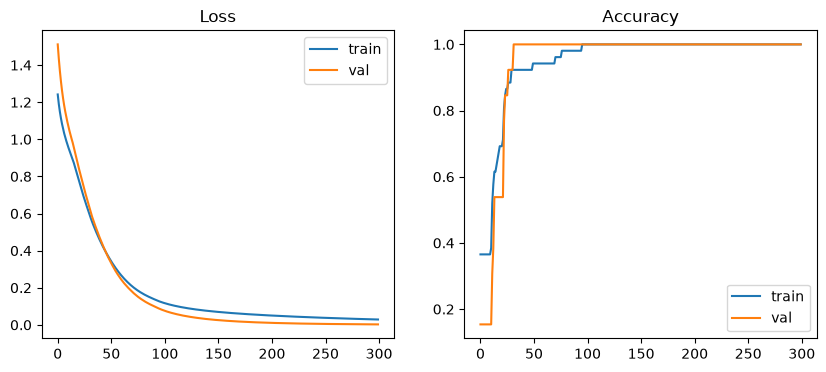

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.show()

## Evaluamos con el set de prueba

Accuracy: 1.0
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         6
       plana       1.00      1.00      1.00         6
        cavo       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



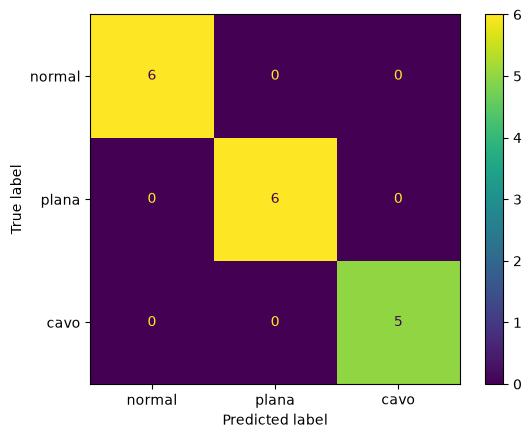

In [9]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy:", accuracy)

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
nombres = list(CLASES.values())
print(classification_report(y_test, y_pred, target_names=nombres, zero_division=0))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=nombres).plot()
plt.show()

## Probamos una pisada nueva
Valores crudos del ADC (0-1023) de S1 a S7.

In [12]:
nueva_pisada = np.array([[944, 943, 891, 891, 0, 936, 936]], dtype="float32") / 1023.0

prediccion = model.predict(nueva_pisada, verbose=0)
clase = prediccion.argmax(axis=1)[0]

print("Diagnóstico:", nombres[clase])
for n, p in zip(nombres, prediccion[0]):
    print(f"{n}: {p:.2f}")

#cavo: [945, 943, 957, 0, 0, 937, 937]
#plano: [962, 959, 567, 567, 567, 951, 951]
#normal: [944, 943, 891, 891, 0, 936, 936]

Diagnóstico: normal
normal: 1.00
plana: 0.00
cavo: 0.00
